# Testing the model

In this notebook the model is tested considering data collected from different sources.

In [ ]:
from fastai.text.all import load_learner
import pandas as pd
import numpy as np

# Load trained model
path_to_model = r"..\model\album_genre_classifier.pkl"
learn = load_learner(path_to_model)

# Load test data
df_test = pd.read_csv("../data/df_test.csv")

In [11]:
# Split test data on X and y
X_test = df_test["Album"]
y_test = df_test["Genre"]

In [17]:
data = []

for album_name in X_test:
    pred_class, _, probs = learn.predict(album_name)
    data.append({
        "Album": album_name,
        "Prob_black_metal": probs[0].item(),
        "Prob_death_metal": probs[1].item()
    })

In [23]:
y_pred = pd.DataFrame(data)

y_pred["Pred"] = np.where(y_pred["Prob_black_metal"] > 0.5, "Black Metal", "Death Metal")
y_pred

,Album,Prob_black_metal,Prob_death_metal,Pred
0,From Mars to Sirius,0.392083,0.607917,Death Metal
1,Onward To Golgotha,0.415003,0.584997,Death Metal
2,Ordinary Corrupt Human Love,0.286010,0.713990,Death Metal
3,Mare Nostrum,0.548528,0.451472,Black Metal
4,Wintersun,0.518037,0.481963,Black Metal
...,...,...,...,...
194,Il était une forêt...,0.722761,0.277239,Black Metal
195,Left Hand Path,0.500203,0.499797,Black Metal
196,Reek of Putrification,0.521207,0.478793,Black Metal
197,Sons of Northern Darkness,0.406157,0.593843,Death Metal


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred["Pred"]))

              precision    recall  f1-score   support

 Black Metal       0.56      0.68      0.61       100
 Death Metal       0.58      0.45      0.51        99

    accuracy                           0.57       199
   macro avg       0.57      0.57      0.56       199
weighted avg       0.57      0.57      0.56       199



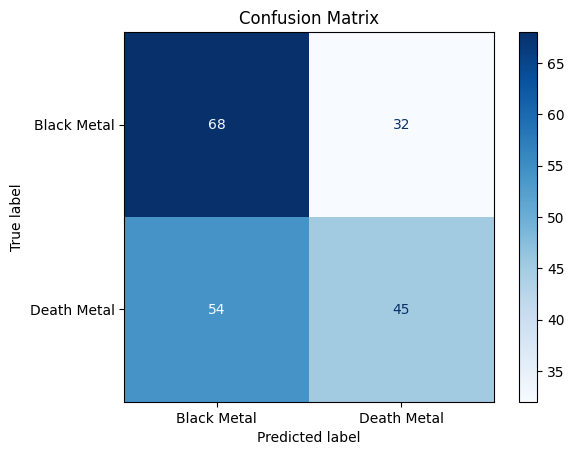

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming y_test is your true labels and y_pred["Pred"] contains predicted labels
cm = confusion_matrix(y_test, y_pred["Pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(y_test)))

# Plot it
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

The model classified more albums (61%) as being black metal, obtaining a nice recall in this category, but failing on the death metal recall. The precision was balanced between both classes.

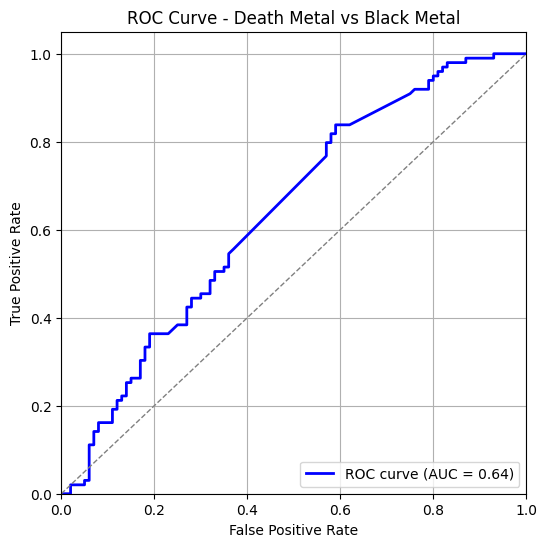

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd

# Encode true labels: Black Metal=0, Death Metal=1
label_map = {"Black Metal": 0, "Death Metal": 1}
y_true = y_test.map(label_map).values

# Probabilities for the positive class (Death Metal)
y_prob = y_pred["Prob_death_metal"].values

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Death Metal vs Black Metal')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The ROC curve and AUC metric indicates that the model is better than a random model.